In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.rsei_utils import aggregate_RSEI
from utils.plot_style import apply_plot_style

apply_plot_style()

In [ ]:
datadir = "/projects/standard/lenkne/oboiko/EJ/data/"
study_period = "2018_2022"
# load and merge the data
huc12 = gpd.read_file(datadir + "aoi_huc12_boundaries.gpkg")
huc12_rsei = pd.read_csv(
    datadir + "huc12_rsei_toxconc_weighted.csv", dtype={"huc12": str}
)
# combine tabular and spatial data using huc12 ids
huc12 = huc12.merge(huc12_rsei, on="huc12")
huc12 = huc12.fillna(0)

ERROR 1: PROJ: proj_create_from_database: Open of /users/2/oboiko/.conda/envs/geo/share/proj failed


In [ ]:
# define area of interest (small bounding box to zoom into)
minx, miny, maxx, maxy = -90.35, 38.66, -90.07, 38.89
bbox = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame({"geometry": bbox}, index=[0], crs="epsg:4326")

In [4]:
# extract huc12
huc12_sel = gpd.overlay(huc12.to_crs(bbox_gdf.crs), bbox_gdf)

In [ ]:
years = list(
    range(int(study_period.split("_")[0]), int(study_period.split("_")[1]) + 1)
)
flowlines = aggregate_RSEI(years, selection_aoi=bbox_gdf, universe="core01")

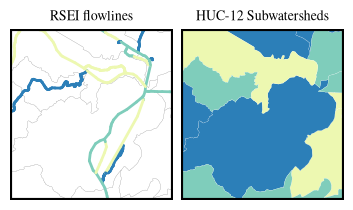

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(3.42, 2), layout="constrained")

# Define your custom colors
custom_colors = ["#edf8b1", "#7fcdbb", "#2c7fb8"]
# Create a ListedColormap from your colors
my_cmap = ListedColormap(custom_colors)

huc12_sel.plot(ax=axs[0], edgecolor="grey", facecolor="None", lw=0.1)
flowlines.to_crs(huc12_sel.crs).plot(
    ax=axs[0],
    column="TOXCONC",
    lw=2,
    ls="-",
    scheme="Quantiles",
    k=3,
    legend=False,
    cmap=my_cmap,
    zorder=1,
    joinstyle="round",
    capstyle="round",
)
huc12_sel.plot(
    ax=axs[1],
    column=f"{study_period}_TOXCONC",
    edgecolor="white",
    scheme="Quantiles",
    k=3,
    lw=0.1,
    legend=False,
    cmap=my_cmap,
)

# Set axis limits to match the bounds exactly
minx, miny, maxx, maxy = bbox_gdf.total_bounds
for ax in [0, 1]:
    bbox_gdf.plot(ax=axs[ax], edgecolor="black", facecolor="None", lw=3)
    axs[ax].set_xlim(minx, maxx)
    axs[ax].set_ylim(miny, maxy)
    axs[ax].axis("off")

axs[0].set_title("RSEI flowlines")
axs[1].set_title("HUC-12 Subwatersheds")

plt.show()

# fig.savefig(f'figures/remapping_rsei.pdf')
fig.savefig(f"../figures/Figure S8.pdf")